In [47]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import scipy.stats as stats

In [2]:
df = pd.read_csv('Household_Dataset_200.csv')

## Types of Data

#### Numerical Columns

In [ ]:
numerical_cols = df.select_dtypes(include=['number']).columns.tolist()
print(f"Numerical Columns: {numerical_cols}")

Numerical Columns: ['Age_of_Household_Head', 'Household_Income', 'Family_Size']


#### Categorical Columns

In [ ]:
categorical_cols = df.select_dtypes(include=['object']).columns.tolist()
print(f"Categorical Columns: {categorical_cols}")

Categorical Columns: ['Household_ID', 'Education_Level', 'Owns_House', 'Urban_Rural']


## Measures of Central Tendency

#### Mean

In [ ]:
mean_vals = df[['Household_Income', 'Age_of_Household_Head']].mean()
print(f"Mean:\n{mean_vals}\n")

Mean:
Household_Income         75720.705
Age_of_Household_Head       50.760
dtype: float64



#### Median

In [ ]:
median_vals = df[['Household_Income', 'Age_of_Household_Head']].median()
print(f"Median:\n{median_vals}\n")

Median:
Household_Income         74767.0
Age_of_Household_Head       51.0
dtype: float64



#### Mode

In [ ]:
mode_vals = df[['Household_Income', 'Age_of_Household_Head']].mode().iloc[0]
print(f"Mode:\n{mode_vals}")

Mode:
Household_Income         15464.0
Age_of_Household_Head       51.0
Name: 0, dtype: float64


## Interpretation of Central Tendency

#### Age

The Mean (50.76) and Median (51.0) are very close to each other.

This indicates that the age distribution is approximately symmetric.

The Mode (51) is also nearly identical, which is expected and acceptable in real-world data.

#### Income

The Mean (75,720.7) and Median (74,767.0) for Household Income are also quite close.

This suggests that the income distribution is approximately normal.

Since the Mean $\approx$ Median, the dataset does not show strong skewness.

## Measures of Dispersion

#### Range

In [ ]:
income_range = df['Household_Income'].max() - df['Household_Income'].min()
print(f"Range: {income_range}")

Range: 123231


#### Variance

In [ ]:
income_variance = df['Household_Income'].var()
print(f"Variance: {income_variance}")

Variance: 786218789.2743467


#### Standard Deviation

In [ ]:
income_std = df['Household_Income'].std()
print(f"Standard Deviation: {income_std}")

Standard Deviation: 28039.59324373923


#### IQR (Interquartile Range)

In [46]:
Q1 = df['Household_Income'].quantile(0.25)
Q3 = df['Household_Income'].quantile(0.75)

IQR = Q3 - Q1

print("Q1 (25th Percentile):", Q1)
print("Q3 (75th Percentile):", Q3)
print("IQR:", IQR)

Q1 (25th Percentile): 53874.75
Q3 (75th Percentile): 93177.0
IQR: 39302.25


## Comment on Income Spread

The calculated IQR of ₹39,302.25 indicates a broad spread within the middle 50% of the household income data. 

This high variability suggests significant economic diversity among the households, as the core income group is distributed over a wide range rather than being tightly clustered.

## Distribution

#### Histogram of Household Income

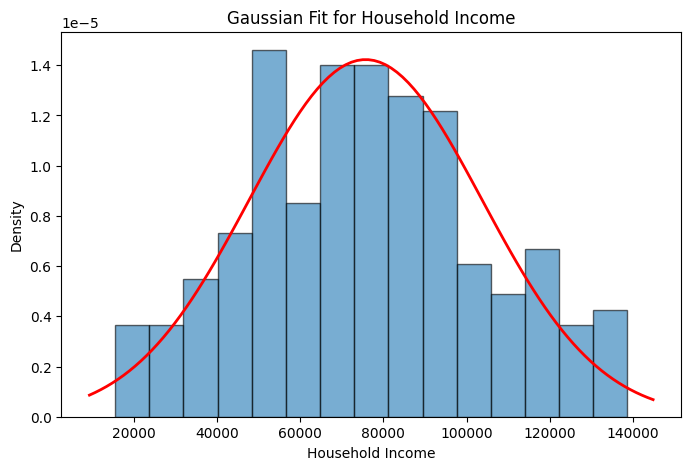

In [ ]:
income = df["Household_Income"]

mu = income.mean()
sigma = income.std()

plt.figure(figsize=(8,5))
plt.hist(income, bins=15, density=True, edgecolor='black', alpha=0.6)

xmin, xmax = plt.xlim()
x = np.linspace(xmin, xmax, 100)

p = stats.norm.pdf(x, mu, sigma)

plt.plot(x, p, 'r', linewidth=2)

plt.title("Gaussian Fit for Household Income")
plt.xlabel("Household Income")
plt.ylabel("Density")

plt.show()

#### Skewness and Kurtosis – Household Income

In [50]:
skew_income = df["Household_Income"].skew()

kurt_income = df["Household_Income"].kurt()

print("Skewness of Household Income:", skew_income)
print("Kurtosis of Household Income:", kurt_income)

Skewness of Household Income: 0.12208102647408059
Kurtosis of Household Income: -0.5277328916385944


## Data Categorization

#### Income Comparison Across Education Levels (Box Plot)

C:\Users\admin\AppData\Local\Temp\ipykernel_20708\1240301320.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Education_Level', y='Household_Income', data=df, palette='Set2')


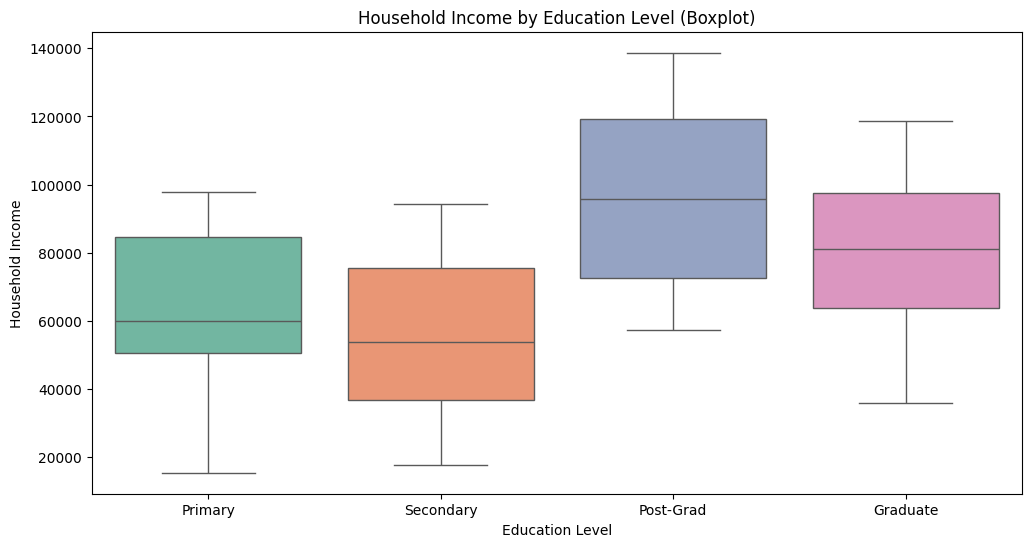

In [55]:
plt.figure(figsize=(12, 6))
sns.boxplot(x='Education_Level', y='Household_Income', data=df, palette='Set2')
plt.title('Household Income by Education Level (Boxplot)')
plt.xlabel('Education Level')
plt.ylabel('Household Income')
plt.show()

#### Urban/Rural (Histogram)

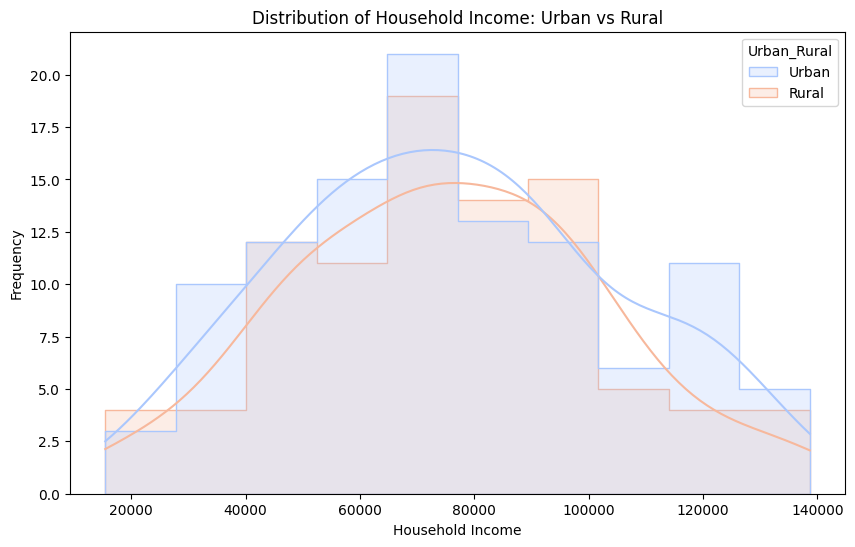

In [56]:
plt.figure(figsize=(10, 6))
sns.histplot(data=df, x='Household_Income', hue='Urban_Rural', kde=True, palette='coolwarm', element='step')
plt.title('Distribution of Household Income: Urban vs Rural')
plt.xlabel('Household Income')
plt.ylabel('Frequency')
plt.show()

## Visualizations

#### Histogram and KDE (Kernel Density Estimation) plot

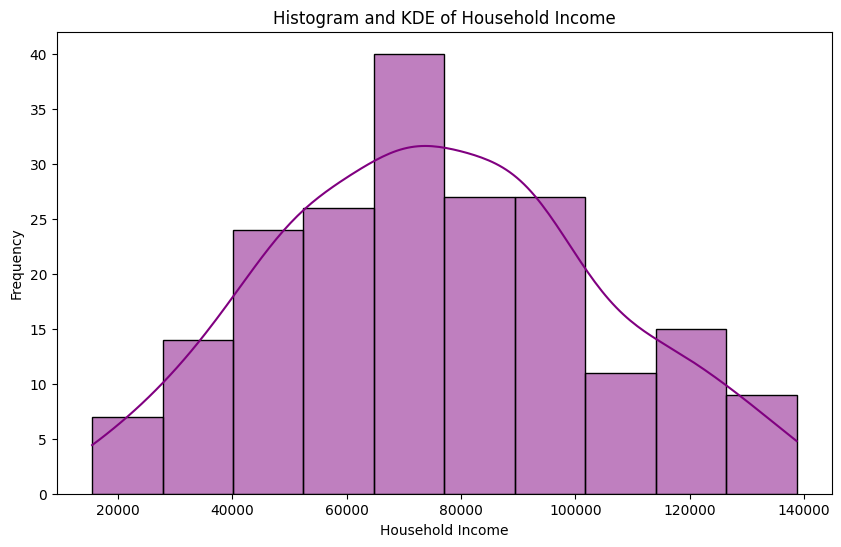

In [57]:
plt.figure(figsize=(10, 6))
sns.histplot(df['Household_Income'], kde=True, color='purple')
plt.title('Histogram and KDE of Household Income')
plt.xlabel('Household Income')
plt.ylabel('Frequency')
plt.show()

#### Boxplot: Family Size vs Education Level


C:\Users\admin\AppData\Local\Temp\ipykernel_20708\1904937796.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Education_Level', y='Family_Size', data=df, palette='pastel')


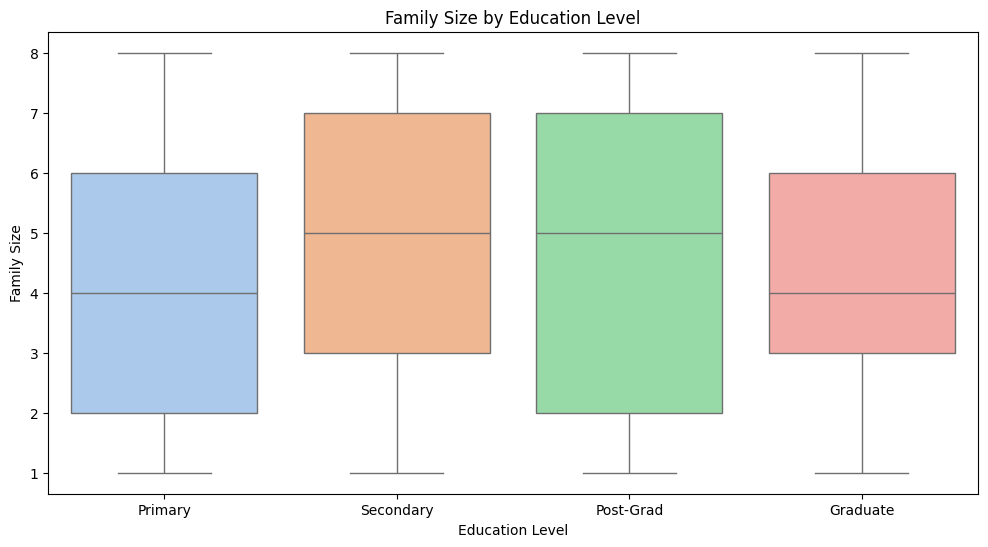

In [60]:

plt.figure(figsize=(12, 6))
sns.boxplot(x='Education_Level', y='Family_Size', data=df, palette='pastel')
plt.title('Family Size by Education Level')
plt.xlabel('Education Level')
plt.ylabel('Family Size')
plt.show()

#### Age vs. Income Distribution Curve

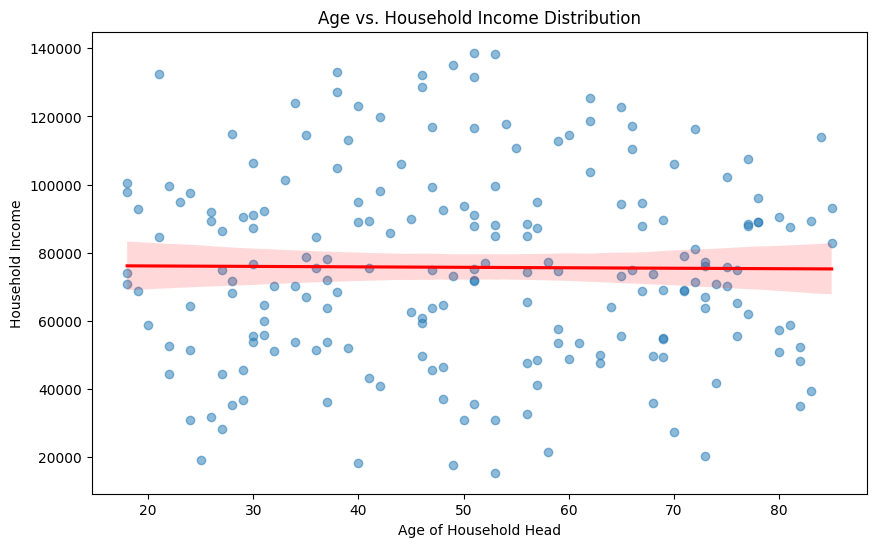

In [ ]:
plt.figure(figsize=(10, 6))
sns.regplot(x='Age_of_Household_Head', y='Household_Income', data=df, scatter_kws={'alpha':0.5}, line_kws={'color':'red'})
plt.title('Age vs. Household Income Distribution')
plt.xlabel('Age of Household Head')
plt.ylabel('Household Income')
plt.show()